# Chapter 55: Pancake Sorting as a Constructed Search Example

**Under the same beam width, how many instances does each ranking actually solve, and how far from optimal are its solutions?**

A beam search is only as good as the ranking that decides what to keep. A ranking that looks sensible, like the number of misplaced positions, can fail to finish, and a failed run with an almost sorted state is still a failure.

*Constructed puzzle and instances; the gap ranking is unusually well matched to pancake flipping, so the gulf between the two rankings overstates what a generic ranking would give. Widening the beam closes much of it.*

## The experiment

Eight pancakes, so 40,320 states. A breadth-first search from the sorted order gives the optimal flip count of every state. On 200 random starting orders, beam search expands all flips of every state in the beam, drops repeated states, and keeps the best W by a ranking: the number of misplaced positions, the gap count (adjacent pancakes that differ by more than one, a published ranking for this puzzle that never overestimates the true flip count), or no ranking at all. A run that has not reached the sorted order within 12 flips fails. Every returned flip list is replayed to confirm that it sorts the start.

In [1]:
import itertools
from functools import lru_cache

import numpy as np
from scipy.stats import spearmanr

from kaggle_companion.activities._common import clean

SEED = 55
N = 8                    # pancakes: 8! = 40,320 states, small enough to know the true answer for every state
INSTANCES = 200          # random starting orders, the same for every policy and width
MAX_FLIPS = 12           # a beam that has not reached the goal after 12 flips reports failure (the longest optimum is 9)


def flip(state, k):
    """Reverse the first k entries; a legal move needs k >= 2."""
    return state[:k][::-1] + state[k:]


@lru_cache(maxsize=None)
def state_space():
    """Every state, its neighbours, the optimal flip count of every state (breadth-first from the goal) and two rankings."""
    states = list(itertools.permutations(range(N)))
    index = {s: i for i, s in enumerate(states)}
    neighbours = np.array([[index[flip(s, k)] for k in range(2, N + 1)] for s in states])
    goal = index[tuple(range(N))]
    optimal = np.full(len(states), -1)
    optimal[goal] = 0
    frontier = [goal]
    while frontier:                                   # each flip costs 1, so breadth-first order gives optimal distances
        nxt = []
        for u in frontier:
            for v in neighbours[u]:
                if optimal[v] < 0:
                    optimal[v] = optimal[u] + 1
                    nxt.append(v)
        frontier = nxt
    P = np.array(states)
    misplaced = (P != np.arange(N)).sum(axis=1)       # the chapter's ranking: positions holding the wrong value
    # Gap count: adjacent pairs, with a final plate of size N, that differ by more than 1.
    gaps = (np.abs(np.diff(np.concatenate([P, np.full((len(P), 1), N)], axis=1), axis=1)) != 1).sum(axis=1)
    return states, neighbours, goal, optimal, misplaced, gaps


def beam_search(start, width, score, rng):
    """Beam search that returns a verified flip list on success and None on failure, plus the states generated."""
    states, neighbours, goal, _, _, _ = state_space()
    parent = np.full(len(states), -1)
    move = np.zeros(len(states), dtype=int)
    seen = np.zeros(len(states), dtype=bool)
    seen[start] = True
    frontier, generated = np.array([start]), 0
    for _ in range(MAX_FLIPS):
        if start == goal:
            break
        children = neighbours[frontier].ravel()
        generated += len(children)
        sources = np.repeat(frontier, N - 1)
        flips = np.tile(np.arange(2, N + 1), len(frontier))
        children, first = np.unique(children, return_index=True)
        sources, flips = sources[first], flips[first]
        fresh = ~seen[children]
        children, sources, flips = children[fresh], sources[fresh], flips[fresh]
        seen[children] = True
        parent[children], move[children] = sources, flips
        if seen[goal] and goal in children:
            break
        if len(children) == 0:
            return None, generated, frontier
        order = np.argsort(score[children] + 0.5 * rng.random(len(children)))   # random tie-break
        frontier = children[order[:width]]
    else:
        return None, generated, frontier
    path, node = [], goal
    while node != start:
        path.append(int(move[node]))
        node = parent[node]
    path.reverse()
    reached = states[start]                           # replay every returned move before trusting it
    for k in path:
        reached = flip(reached, k)
    assert reached == tuple(range(N)), "replay did not reach the goal"
    return path, generated, frontier


def run(beam_width):
    states, _, _, optimal, misplaced, gaps = state_space()
    starts = np.random.default_rng(SEED).integers(0, len(states), INSTANCES)
    rankings = {"misplaced": misplaced.astype(float), "gap": gaps.astype(float), "random": np.zeros(len(states))}
    out = {}
    for name, score in rankings.items():
        rng = np.random.default_rng(SEED + 1)
        solved, excess, generated, near_miss = 0, [], [], 0
        for s in starts:
            path, gen, frontier = beam_search(s, beam_width, score, rng)
            generated.append(gen)
            if path is None:
                near_miss += int(misplaced[frontier].min() <= 2)   # an unfinished path that looks almost sorted
            else:
                solved += 1
                excess.append(len(path) - optimal[s])
        out[name] = {"solve_rate": solved / INSTANCES,
                     "excess_flips": float(np.mean(excess)) if excess else None,
                     "states_generated": float(np.mean(generated)),
                     "failures": INSTANCES - solved, "near_miss_failures": near_miss}
    return clean({
        "beam_width": beam_width, "policies": out,
        "misplaced_overestimates": float((misplaced > optimal).mean()),   # share of all 40,320 states
        "gap_overestimates": float((gaps > optimal).mean()),
        # what a beam actually uses is the order: how well does each ranking track the true distance over all states?
        "misplaced_rank_corr": float(spearmanr(misplaced, optimal)[0]),
        "gap_rank_corr": float(spearmanr(gaps, optimal)[0]),
        "mean_optimal_flips": float(optimal.mean()), "max_optimal_flips": int(optimal.max()),
        "instances": INSTANCES, "states": len(states),
    })


## Measure it across the control

The control is **beam width (states kept after each flip)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch55 import explain

VALUES = [1, 4, 16, 64]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                             1              4             16             64
Misplaced ranking, solved                 0.5%            21%            71%          99.5%
Gap ranking, solved                        92%           100%           100%           100%
No ranking, solved                          0%           0.5%             2%             8%
Gap minus misplaced, solve rate          0.910          0.790          0.290          0.005
Misplaced overestimates          45% of states  45% of states  45% of states  45% of states


## Look at it

The figure shows the default setting, beam width (states kept after each flip) = 4.

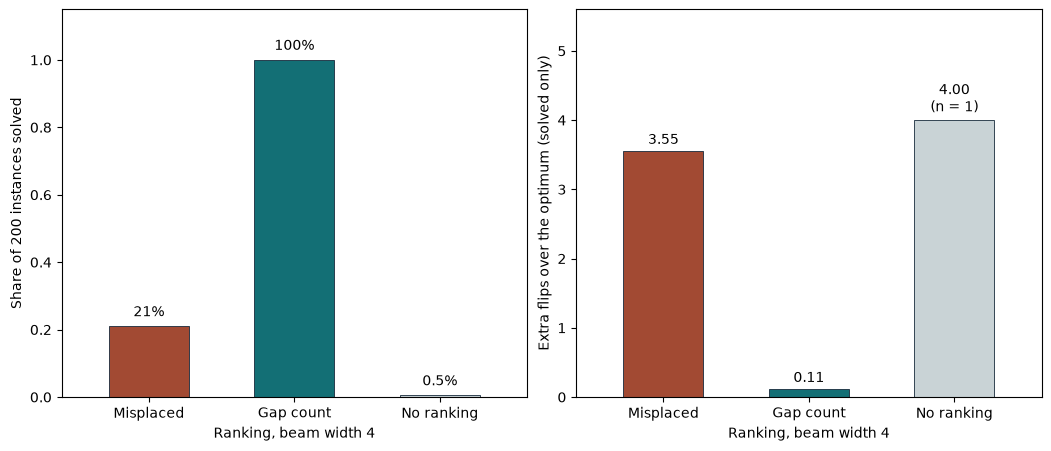

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch55 import draw, NCOLS, HEIGHT

DEFAULT = 4
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With a beam width of 4, the misplaced-position ranking solves 21% of 200 instances and the gap count 100%, so 1.000 - 0.210 = 0.790 of the instances separate them; with no ranking 0.5% are solved. Solved runs use 3.55 extra flips for the misplaced ranking and 0.11 for the gap count. The misplaced count overestimates the true flips left in 45% of all 40,320 states and the gap count in 0%, and their rank correlations with the true flips left are 0.06 and 0.85. The gap beam generates 169 states per instance and the misplaced beam 300.

- Solve rate gap minus misplaced: 1.000 - 0.210 = +0.790.
- Failed misplaced runs that ended within 2 positions of sorted: 26 of 158 (still failures).
- Share of states where the misplaced count exceeds the true flips left: 45%.
- Mean optimal flips over all 40,320 states: 6.64, longest 9.

## Apply this to your competition

- Return a verified completed solution or an explicit failure, and replay every returned move list with the official validator.
- Get optimal or best-known answers on small instances by exhaustive search before trusting a heuristic on large ones.
- Test whether a ranking tracks the real remaining cost on small solved instances, for example by its rank correlation with the exact distance; a loosely tracking ranking loses the path unless the beam is wide.
- Compare policies at the same budget (states generated, width, time) and report solve rate and excess over the baseline, not only the best score reached.

Book location: Chapter 55, A Heuristic Is Not Automatically a Lower Bound.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)